***Project Title : Machine Learning based Demand Prediction System:*** 

**Step No : 1 Project Overview :** 

**Problem Statement**

An FMCG company entered the instant noodles segment two years ago. 
The management observed a mismatch between demand and supply across warehouses. 

In high-demand regions, supply is insufficient, leading to stock-outs, 
while in low-demand regions, excess inventory results in increased holding costs.

This imbalance causes significant financial loss. 
Therefore, the objective is to optimize the supply quantity for each warehouse 
based on demand patterns to reduce inventory costs and improve supply chain efficiency.

***Goal & Objectives :***
- This exercise aims to build a machine learning model using historical data to determine the optimal quantity of product to be shipped to each warehouse.

- Additionally, the objective is to analyze demand patterns across different regions so that management can make informed decisions for targeted advertisement campaigns.

- This is the first phase of the project, where limited data is provided. Based on the performance and impact of this phase, the company may provide access to a complete 360-degree data lake to develop a more robust and scalable solution. 

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\sagar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


**Step No : 2 Importing Required Libraries :** 

In [2]:
# Import Required Libraries
# Importing basic libraries for numerical operations and data handling
import numpy as np  
import pandas as pd 

# Importing visualization libraries to create charts and graphs
import matplotlib.pyplot as plt 
import seaborn as sns 

# ML Models & Utilities 
from sklearn.model_selection import train_test_split , cross_val_score , RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor 

# Evaluation metrics 
from sklearn.metrics import mean_absolute_error , r2_score

# Feature scaling 
from sklearn.preprocessing import StandardScaler

**Step No : 3 Loading Dataset**

In [3]:
# Load Dataset 
df = pd.read_csv("Dataset.csv")

# Clean column names (remove extra spaces )
df.columns = df.columns.str.strip()

# Preview Data 
df

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,WH_124995,EID_74995,Rural,Small,North,Zone 1,3,0,4,5390,...,1,142,34.0,2005.0,22,1,A,2,30,32093
24996,WH_124996,EID_74996,Rural,Mid,West,Zone 2,6,0,4,4490,...,1,130,28.0,2012.0,10,0,B,4,18,12114
24997,WH_124997,EID_74997,Urban,Large,South,Zone 5,7,0,2,5403,...,1,147,NaN,NaN,23,0,B+,5,25,27080
24998,WH_124998,EID_74998,Rural,Small,North,Zone 1,1,0,2,10562,...,1,60,25.0,NaN,18,0,A,6,30,25093


**Step 4 : Data Understanding**

In [4]:
# Data Understanding 
# Check dataset size (rows , columns )
print("Dataset Shape : ", df.shape)

# Get basic info (columns , data types , null values)
print("\nDataset Info : ")
df.info()

# View Statistical summary of numerical features 
print("\nStatistical Summary : ")
print(df.describe())

# Check Missing Values in each column
print("\nMissing Values : ")
print(df.isnull().sum())

# Check Duplicate rows in dataset 
print("\nDuplicate Rows : " , df.duplicated().sum())


Dataset Shape :  (25000, 24)

Dataset Info : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ware_house_ID                 25000 non-null  object 
 1   WH_Manager_ID                 25000 non-null  object 
 2   Location_type                 25000 non-null  object 
 3   WH_capacity_size              25000 non-null  object 
 4   zone                          25000 non-null  object 
 5   WH_regional_zone              25000 non-null  object 
 6   num_refill_req_l3m            25000 non-null  int64  
 7   transport_issue_l1y           25000 non-null  int64  
 8   Competitor_in_mkt             25000 non-null  int64  
 9   retail_shop_num               25000 non-null  int64  
 10  wh_owner_type                 25000 non-null  object 
 11  distributor_num               25000 non-null  int64  
 12  flood_impacted

**Step No : 5 Data Cleaning / Preprocessing**

In [5]:
# Data Cleaning / Preprocessing
# Fill missing values in 'workers_num' using median (robust to outliers) 
df['workers_num'] = df['workers_num'].fillna(df['workers_num'].median())

In [6]:
# Verify that there are no missing values left in 'workers_num'
print(df['workers_num'].isnull().sum())

0


In [7]:
# Check Missing Values in each column
print("\nMissing Values : ")
print(df.isnull().sum())



Missing Values : 
Ware_house_ID                       0
WH_Manager_ID                       0
Location_type                       0
WH_capacity_size                    0
zone                                0
WH_regional_zone                    0
num_refill_req_l3m                  0
transport_issue_l1y                 0
Competitor_in_mkt                   0
retail_shop_num                     0
wh_owner_type                       0
distributor_num                     0
flood_impacted                      0
flood_proof                         0
electric_supply                     0
dist_from_hub                       0
workers_num                         0
wh_est_year                     11881
storage_issue_reported_l3m          0
temp_reg_mach                       0
approved_wh_govt_certificate      908
wh_breakdown_l3m                    0
govt_check_l3m                      0
product_wg_ton                      0
dtype: int64


In [ ]:

# Step 1: Check Missing Value

# Check missing values in all columns
print("Missing Values:\n")
print(df.isnull().sum())

# Step 2: Handle 'workers_num'

# Fill missing values in 'workers_num' using median (robust to outliers)
df['workers_num'] = df['workers_num'].fillna(df['workers_num'].median())

# Step 3: Handle 'approved_wh_govt_certificate'

# Fill missing values using mode (most frequent value - suitable for categorical/binary data)
df['approved_wh_govt_certificate'] = df['approved_wh_govt_certificate'].fillna(
    df['approved_wh_govt_certificate'].mode()[0]
)
# Step 4: Handle 'wh_est_year' 

# Create missing indicator (1 = missing, 0 = not missing)
df['wh_est_year_missing'] = df['wh_est_year'].isnull().astype(int)

# Fill missing values using median
df['wh_est_year'] = df['wh_est_year'].fillna(df['wh_est_year'].median())

# Step 5: Final Check

# Verify that no missing values remain
print("\nFinal Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Ware_house_ID                       0
WH_Manager_ID                       0
Location_type                       0
WH_capacity_size                    0
zone                                0
WH_regional_zone                    0
num_refill_req_l3m                  0
transport_issue_l1y                 0
Competitor_in_mkt                   0
retail_shop_num                     0
wh_owner_type                       0
distributor_num                     0
flood_impacted                      0
flood_proof                         0
electric_supply                     0
dist_from_hub                       0
workers_num                         0
wh_est_year                     11881
storage_issue_reported_l3m          0
temp_reg_mach                       0
approved_wh_govt_certificate      908
wh_breakdown_l3m                    0
govt_check_l3m                      0
product_wg_ton                      0
dtype: int64

Final Missing Values:

Ware_house_ID                   0


In [9]:
# Final dataset shape
print("Shape:", df.shape)

# Final missing values check
print("\nMissing Values:\n")
print(df.isnull().sum())

# Duplicate check
print("\nDuplicate Rows:", df.duplicated().sum())

# Columns list
print("\nColumns:\n", df.columns)

Shape: (25000, 25)

Missing Values:

Ware_house_ID                   0
WH_Manager_ID                   0
Location_type                   0
WH_capacity_size                0
zone                            0
WH_regional_zone                0
num_refill_req_l3m              0
transport_issue_l1y             0
Competitor_in_mkt               0
retail_shop_num                 0
wh_owner_type                   0
distributor_num                 0
flood_impacted                  0
flood_proof                     0
electric_supply                 0
dist_from_hub                   0
workers_num                     0
wh_est_year                     0
storage_issue_reported_l3m      0
temp_reg_mach                   0
approved_wh_govt_certificate    0
wh_breakdown_l3m                0
govt_check_l3m                  0
product_wg_ton                  0
wh_est_year_missing             0
dtype: int64

Duplicate Rows: 0

Columns:
 Index(['Ware_house_ID', 'WH_Manager_ID', 'Location_type', 'WH_capacity

**Step NO : 6 Exploratory Data Analysis (EDA) :**
- **Objective :**
- Understand data patterns 
- Identify demand drivers 
- Convert insights into business decisions

#### *6.1 Univariate Analysis*

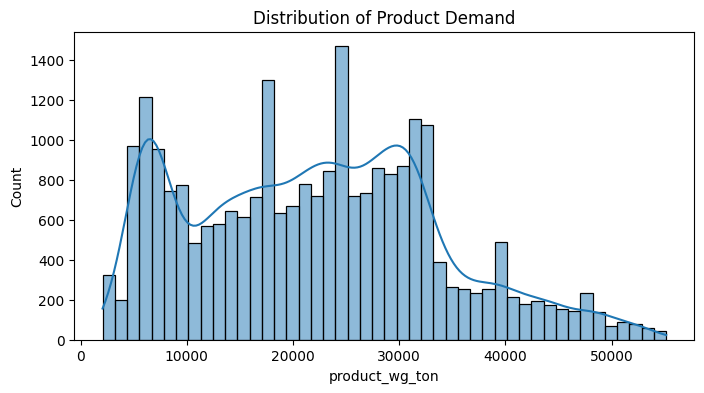

In [10]:
# Target variable Distribution 
plt.figure(figsize=(8,4))
sns.histplot(df["product_wg_ton"], kde = True)
plt.title("Distribution of Product Demand")
plt.show()

# Business Insight:
# Demand is uneven across warehouses
# Action: Use smart inventory allocation

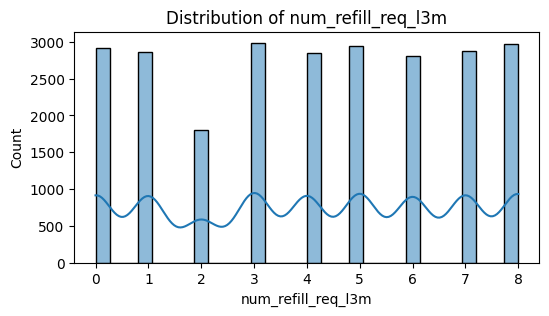

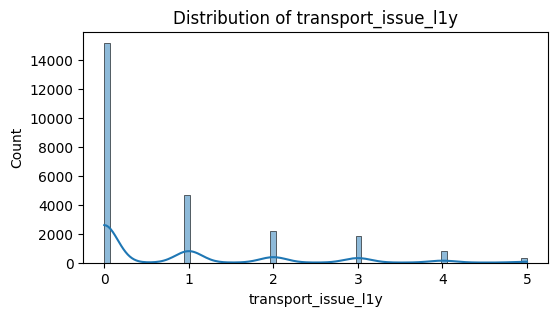

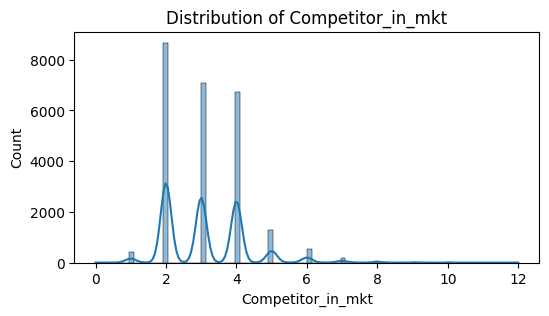

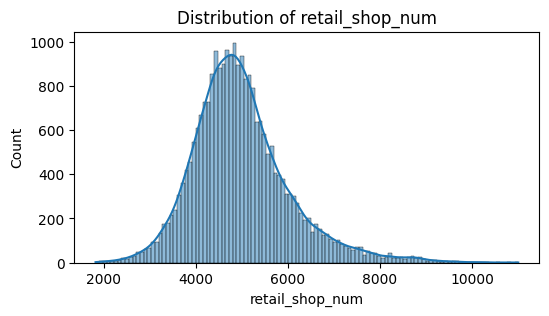

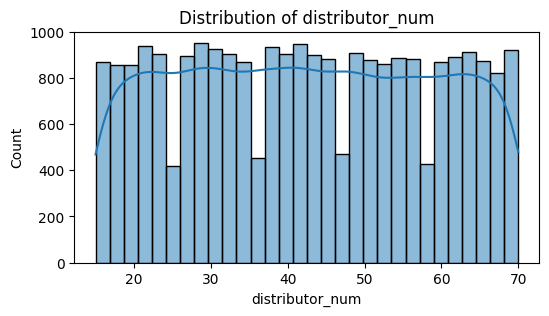

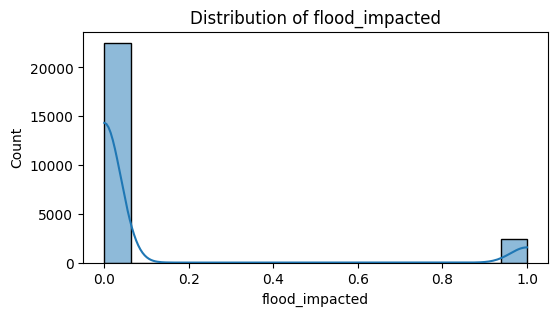

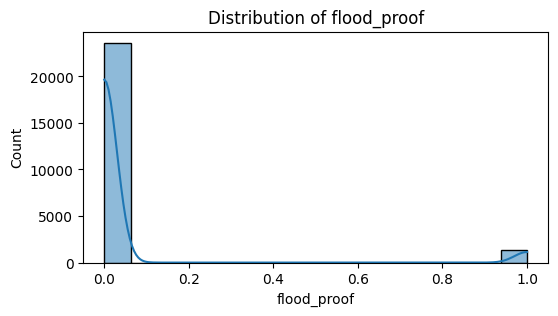

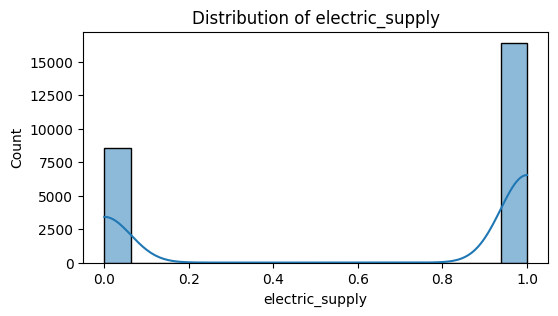

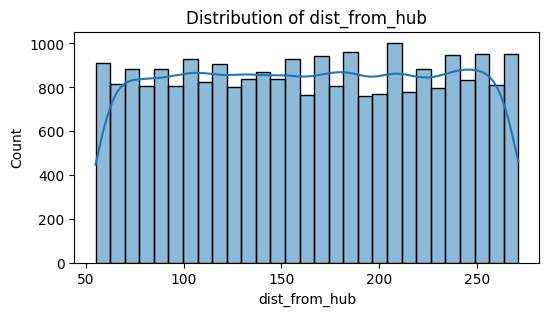

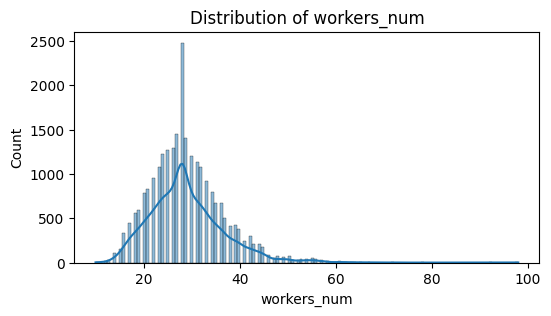

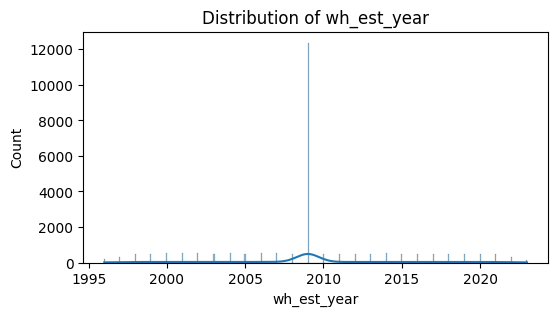

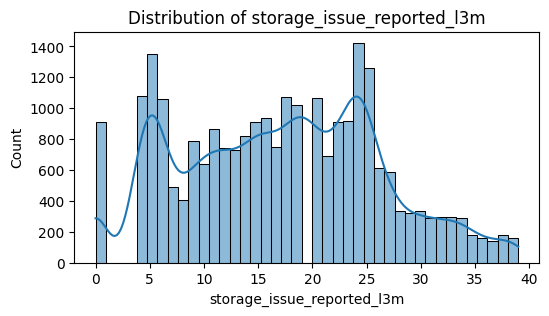

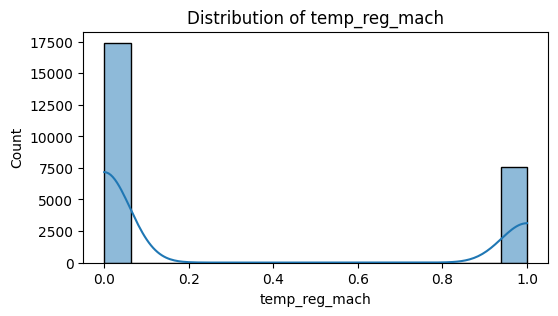

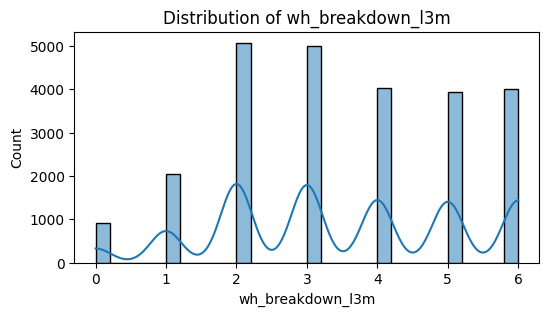

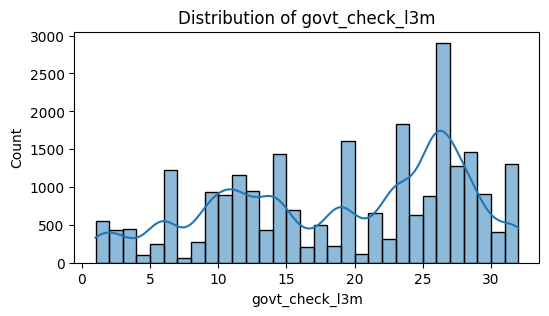

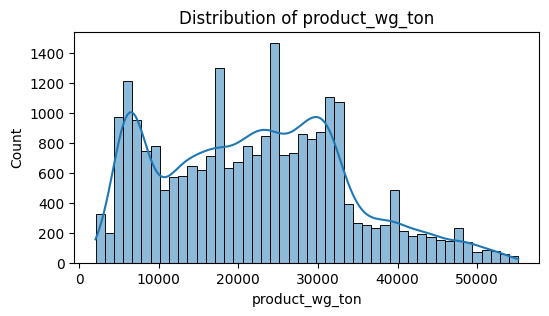

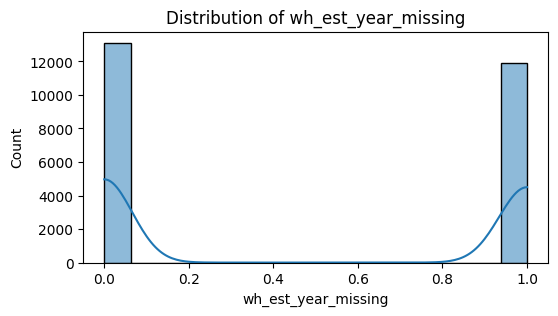

In [11]:
# Numerical Feature 
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col] , kde = True)
    plt.title(f"Distribution of {col}")
    plt.show()
    
# Business Insight:
# Some features are skewed
# Action: Apply log transformation or scaling

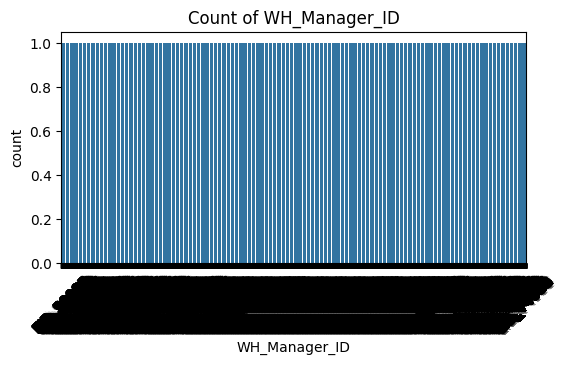

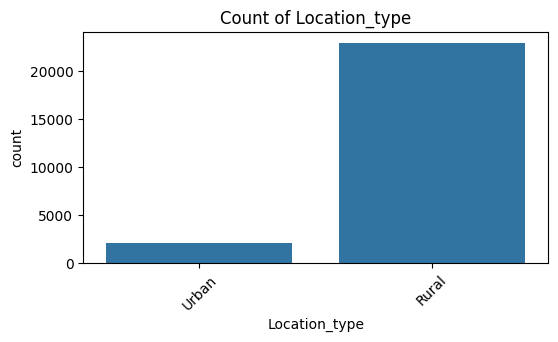

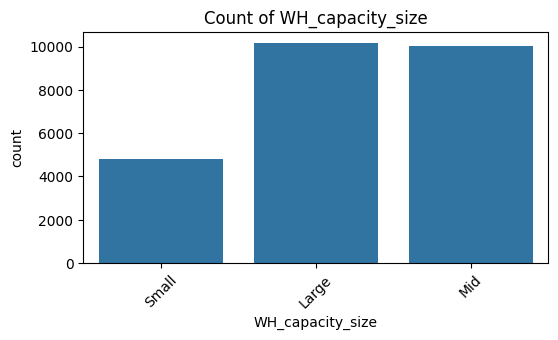

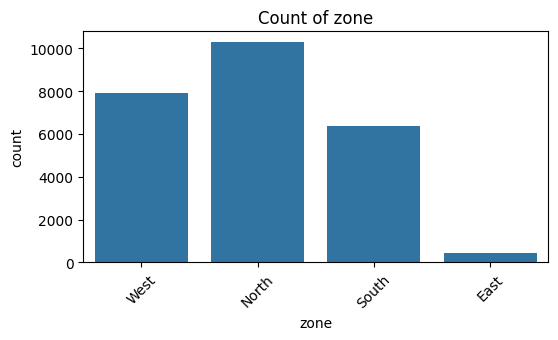

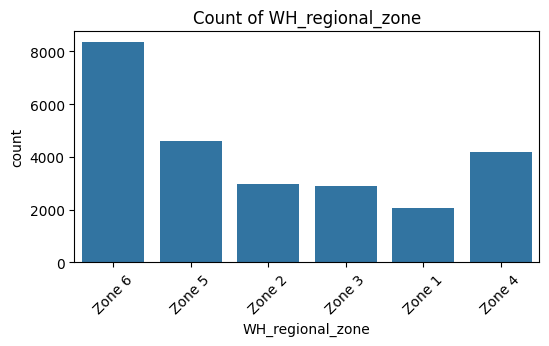

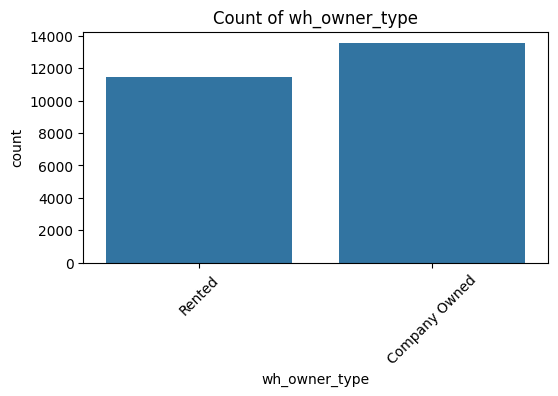

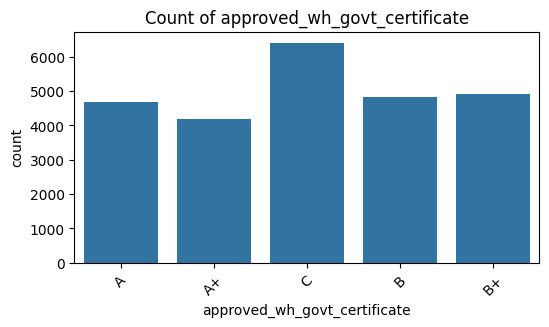

In [12]:
# Categorical Feature 
cat_cols = df.select_dtypes(include="object").columns

# Remove ID column
cat_cols = [col for col in cat_cols if col != "Ware_house_ID"]

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()

# Business Insight:
# Category imbalance observed
# Action: Location-based planning required

#### *6. Bivariate Analysis*

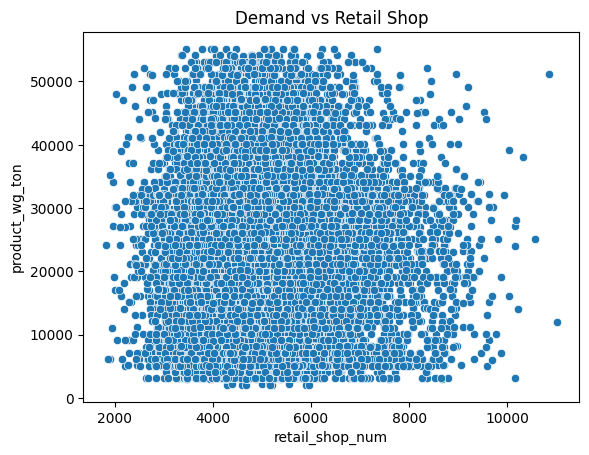

In [13]:
# Retail Shops 
sns.scatterplot(x = "retail_shop_num" , y = "product_wg_ton" , data=df)
plt.title("Demand vs Retail Shop")
plt.show()

# Insight:
# More shops → Higher demand
# Action: Increase supply in such areas

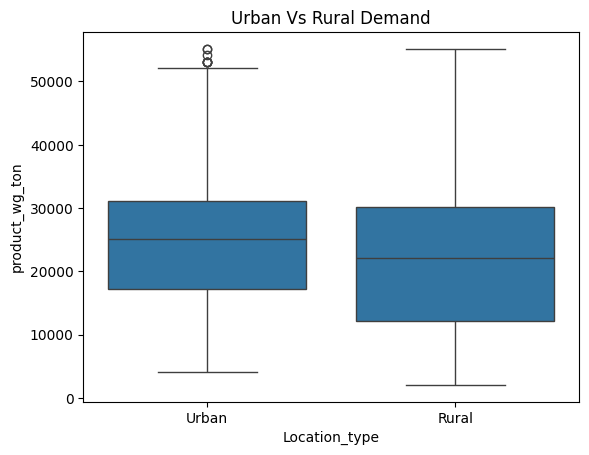

In [14]:
# Location
sns.boxplot(x="Location_type", y="product_wg_ton" , data=df)
plt.title("Urban Vs Rural Demand")
plt.show()

# Insight:
# Urban demand is higher
# Action: Prioritize urban warehouses

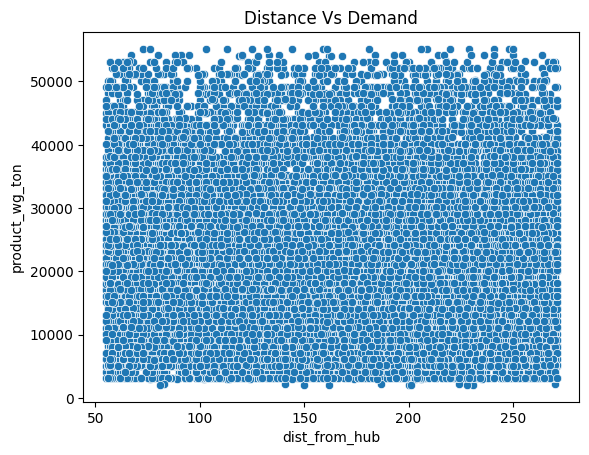

In [15]:
# Distance 
sns.scatterplot(x = "dist_from_hub" , y = "product_wg_ton" , data=df)
plt.title("Distance Vs Demand")
plt.show()

# Insight:
# Higher distance → Lower efficiency
# Action: Improve logistics

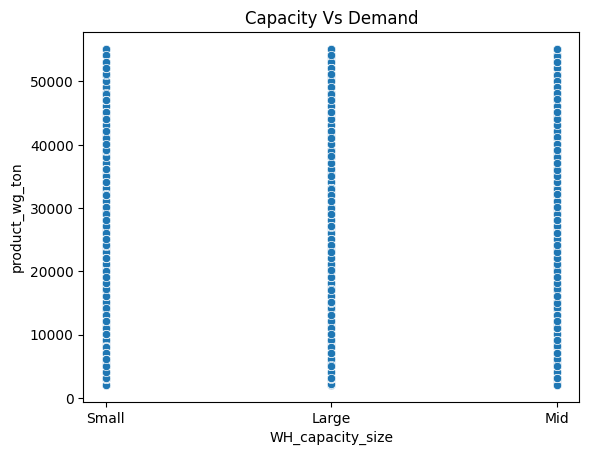

In [16]:
# Capacity
sns.scatterplot(x ="WH_capacity_size" , y = "product_wg_ton" , data=df)
plt.title("Capacity Vs Demand")
plt.show()

# Insight:
# Higher capacity → Better handling
# Action: Allocate more supply

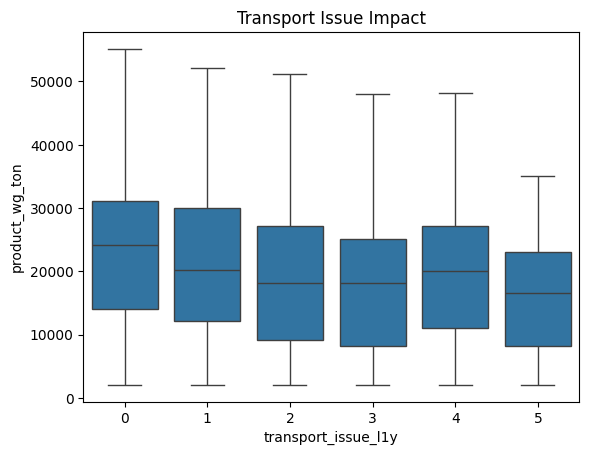

In [17]:
# Transport Issues
sns.boxplot(x = "transport_issue_l1y" , y = "product_wg_ton" , data=df)
plt.title("Transport Issue Impact")
plt.show()

# Insight:
# Transport issues reduce demand fulfillment
# Action: Improve transport system

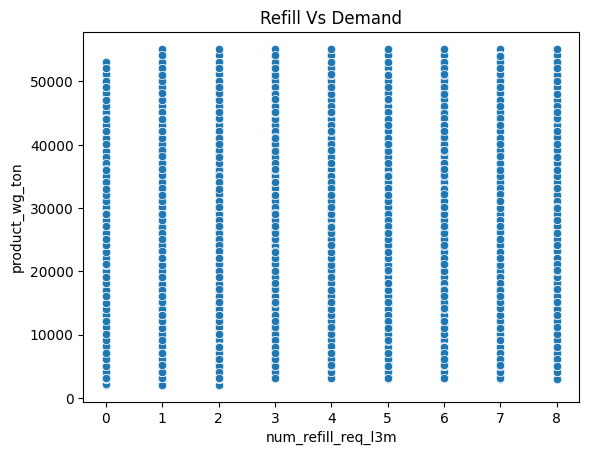

In [18]:
# Refill Requests 
sns.scatterplot(x = "num_refill_req_l3m" , y = "product_wg_ton" , data=df)
plt.title("Refill Vs Demand")
plt.show()

# Insight:
# More refills → Higher demand
# Action: Increase stock in such zones

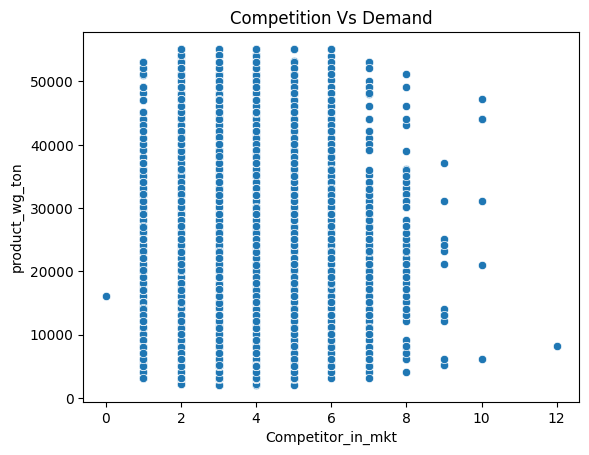

In [19]:
# Competition 
sns.scatterplot(x="Competitor_in_mkt" , y = "product_wg_ton" , data=df)
plt.title("Competition Vs Demand")
plt.show()

# Insight:
# Competition affects demand
# Action: Improve pricing/strategy

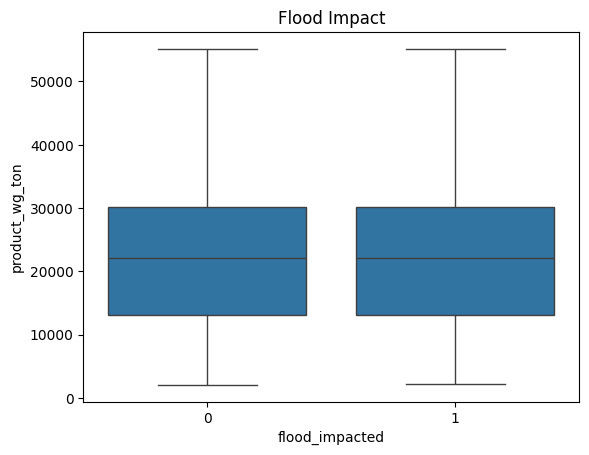

In [20]:
# Flood Impact
sns.boxplot(x = "flood_impacted" , y = "product_wg_ton" , data=df)
plt.title("Flood Impact")
plt.show()

# Insight:
# Flood areas show unstable demand
# Action: Risk-based planning

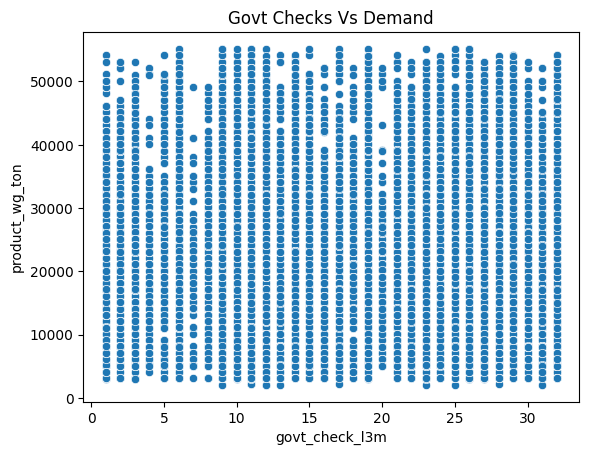

In [21]:
# Govt Checks
sns.scatterplot(x = "govt_check_l3m" , y = "product_wg_ton" , data=df)
plt.title("Govt Checks Vs Demand")
plt.show()

# Insight:
# More checks → slower operations
# Action: Improve compliance

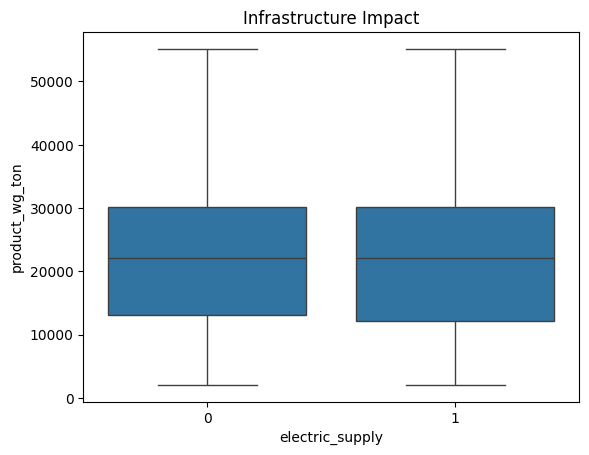

In [22]:
# Infrastructure
sns.boxplot(x = "electric_supply" , y = "product_wg_ton" , data=df)
plt.title("Infrastructure Impact")
plt.show()

# Insight:
# Better infrastructure improves demand handling
# Action: Upgrade weak warehouse

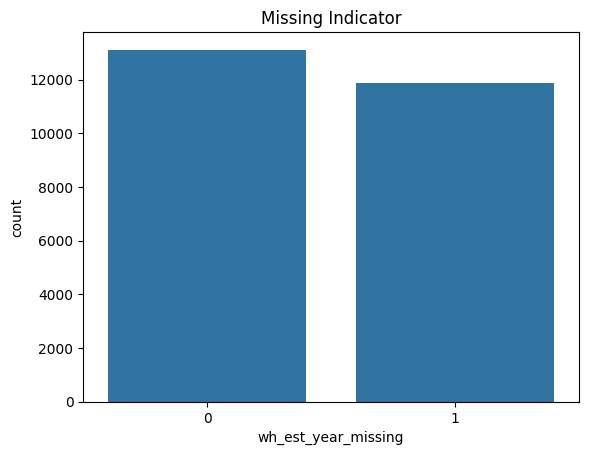

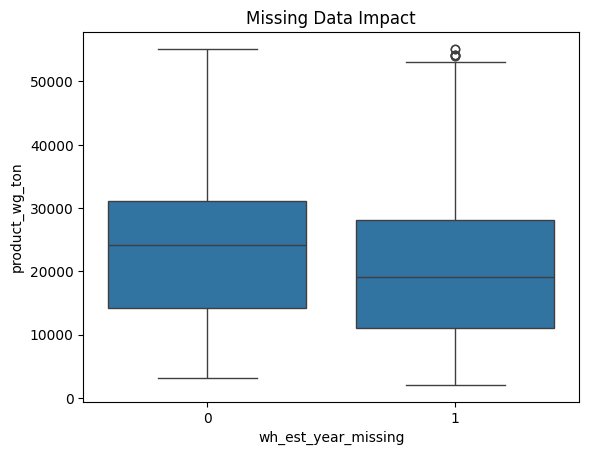

In [23]:
# Missing Indicator

sns.countplot(x = "wh_est_year_missing" , data=df)
plt.title("Missing Indicator")
plt.savefig("images/Missing Indicator_countplot.png")
plt.show()

sns.boxplot(x = "wh_est_year_missing" , y = "product_wg_ton" , data = df)
plt.title("Missing Data Impact")
plt.show()

# Insight:
# Missing data → inconsistent performance
# Action: Improve data quality

#### *6.3 Multivariate Analysis*

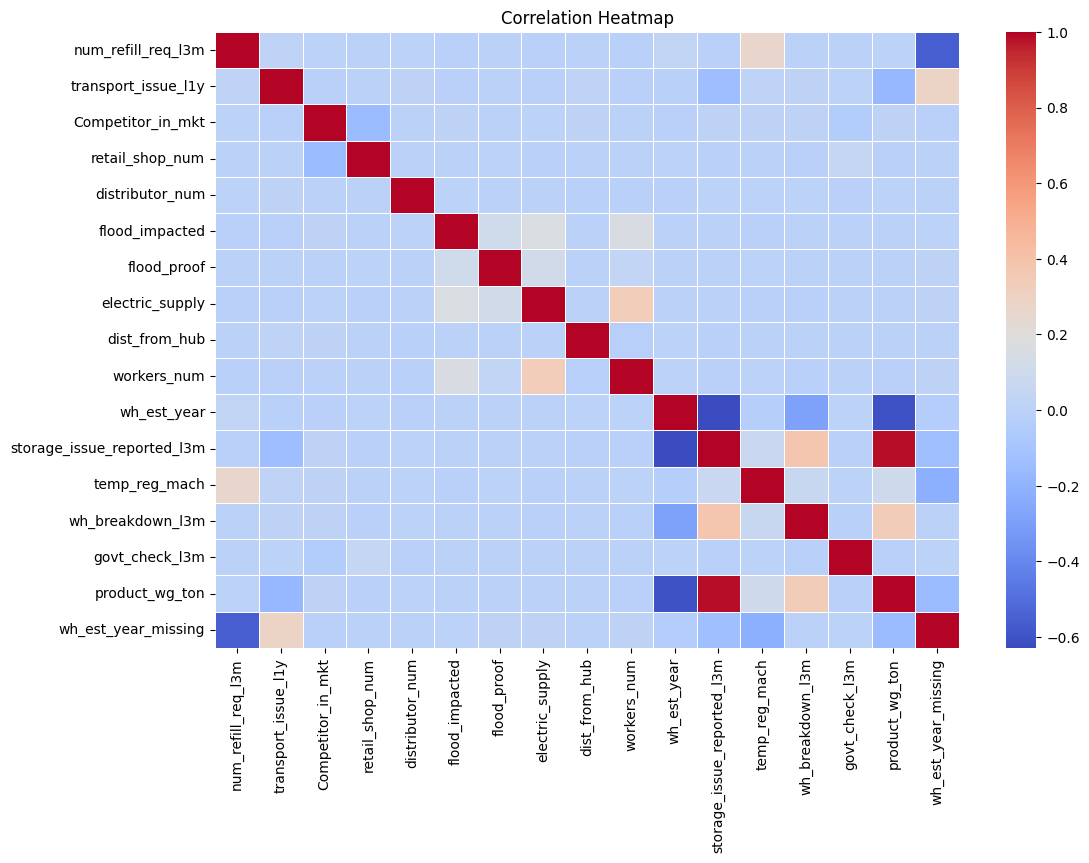

In [24]:
import seaborn as sns
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

# Insight:
# Retail shops, warehouse capacity, and distributors are key drivers of demand
# Action: Prioritize these features in model building and supply planning

In [25]:
# Correlation with target 
corr_target = df.corr(numeric_only=True)["product_wg_ton"].sort_values(ascending=False)

print("Correlation with Target:\n", corr_target)

print("\nSpecific Feature Correlation:")
print(df[["storage_issue_reported_l3m", "product_wg_ton"]].corr())

Correlation with Target:
 product_wg_ton                1.000000
storage_issue_reported_l3m    0.986777
wh_breakdown_l3m              0.342685
temp_reg_mach                 0.101638
Competitor_in_mkt             0.008884
distributor_num               0.004999
num_refill_req_l3m            0.001415
flood_proof                  -0.000441
electric_supply              -0.002160
flood_impacted               -0.002299
dist_from_hub                -0.005017
retail_shop_num              -0.006615
workers_num                  -0.008072
govt_check_l3m               -0.008500
wh_est_year_missing          -0.164117
transport_issue_l1y          -0.173992
wh_est_year                  -0.604957
Name: product_wg_ton, dtype: float64

Specific Feature Correlation:
                            storage_issue_reported_l3m  product_wg_ton
storage_issue_reported_l3m                    1.000000        0.986777
product_wg_ton                                0.986777        1.000000


In [26]:
import scipy.stats as stats

# Example: statistical correlation test
corr, p_value = stats.pearsonr(df["retail_shop_num"], df["product_wg_ton"])

print("\nPearson Correlation:", corr)
print("P-value:", p_value)


Pearson Correlation: -0.006615148824087946
P-value: 0.2956044287646704


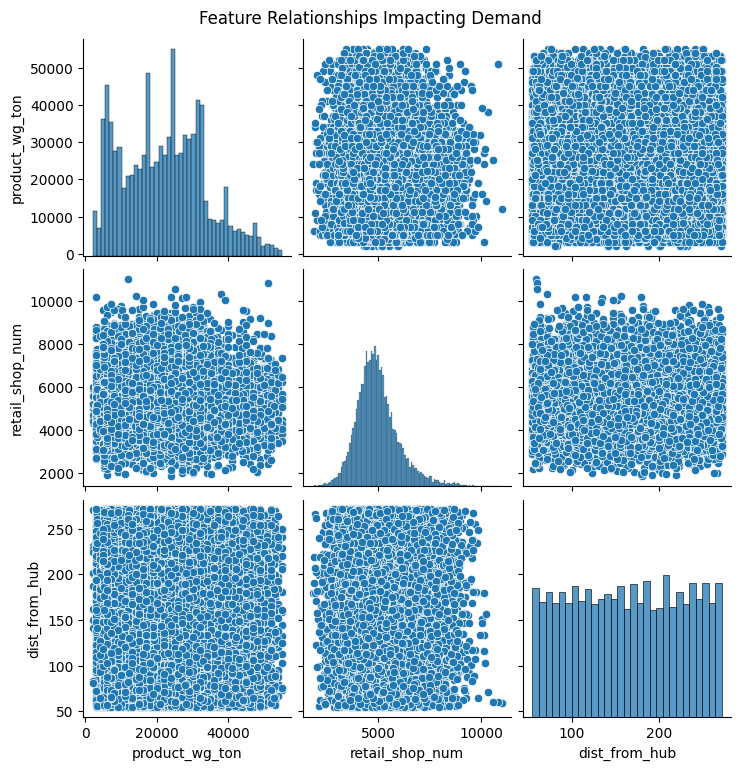

In [27]:
# Pairplot (Important Features)
selected_cols = [
    "product_wg_ton",
    "retail_shop_num",
    "WH_capacity_size",
    "dist_from_hub"
]

sns.pairplot(df[selected_cols])

plt.suptitle("Feature Relationships Impacting Demand", y=1.02)

plt.show()

# Insight:
# Strong relationships observed between demand and key features
# Action: These features should be prioritized for predictive modeling

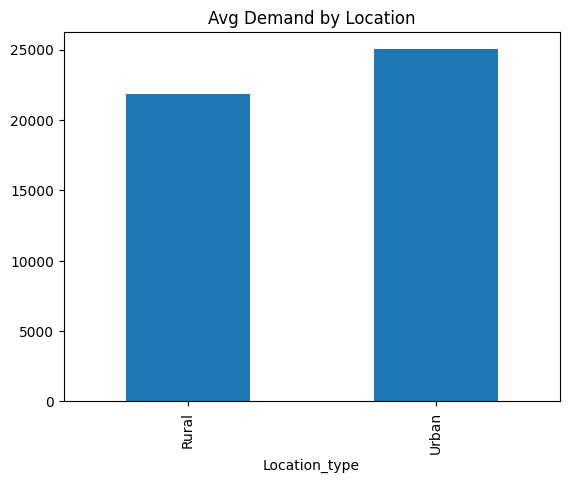

In [28]:
# Grouped Analysis
df.groupby("Location_type")["product_wg_ton"].mean().plot(kind = "bar")
plt.title("Avg Demand by Location")
plt.show()

# Insight:
# Urban demand higher
# Action: Focus on urban supply

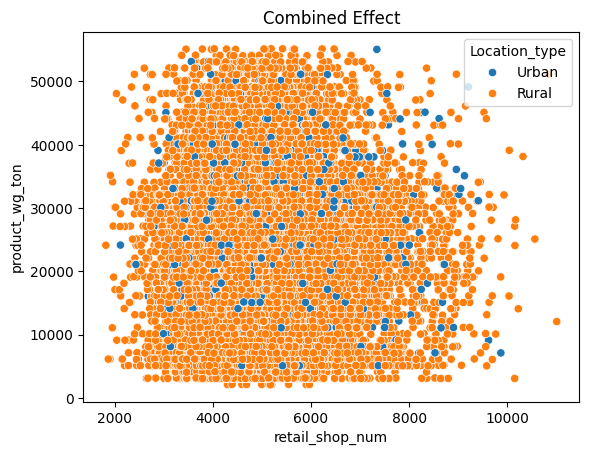

In [29]:
# Combined Effect 
sns.scatterplot(x = "retail_shop_num" , y = "product_wg_ton" , hue = "Location_type", data=df)
plt.title("Combined Effect")
plt.show()

# Insight:
# Urban + high retail → highest demand
# Action: Identify high priority zones

#### **FINAL BUSINESS INSIGHTS**

- 1. High retail areas → high demand → increase supply
- 2. Urban locations → higher demand → prioritize inventory
- 3. Distance & transport → reduce efficiency → improve logistics
- 4. Risk factors → unstable demand → risk-based planning
- 5. Capacity → key driver → optimize allocation
- 6. Competition → impacts demand → strategy needed
- 7. Missing data → unreliable → improve data quality

***Step NO 7 : Feature Engineering***
#### **Objective:**
- Convert raw data into meaningful features
- Improve model performance using business-driven features

In [30]:
# Step 7.1 : Log Transformation 

df["log_dist_from_hub"] = np.log1p(df["dist_from_hub"])
df["log_retail_shop"] = np.log1p(df["retail_shop_num"])
df["log_distributor"] = np.log1p(df["distributor_num"])

# Insight:
# Reduces skewness and stabilizes variance
# Improves model performance

In [31]:
# Step 2 : Demand - Based Features
df["demand_per_shop"] = df["product_wg_ton"] / (df["retail_shop_num"] + 1)
df["demand_per_distributor"] = df["product_wg_ton"] / (df["distributor_num"] + 1)

# Insight:
# Captures demand efficiency per unit

In [32]:
# Step 3 : Werehouse Efficiency
# Step 1: Convert to numeric (IMPORTANT)
df["workers_num"] = pd.to_numeric(df["workers_num"], errors="coerce")
df["retail_shop_num"] = pd.to_numeric(df["retail_shop_num"], errors="coerce")
df["product_wg_ton"] = pd.to_numeric(df["product_wg_ton"], errors="coerce")
df["WH_capacity_size"] = pd.to_numeric(df["WH_capacity_size"], errors="coerce")

# Step 2: Feature Engineering
df["worker_efficiency"] = df["workers_num"] / (df["retail_shop_num"] + 1)

df["capacity_utilization"] = df["product_wg_ton"] / (df["WH_capacity_size"] + 1)

# Insight:
# Measures how efficiently warehouse resources are used

In [33]:
# Step 4 : Risk Score 
df["risk_score"] =(
    df["transport_issue_l1y"] +
    df["wh_breakdown_l3m"] + 
    df["storage_issue_reported_l3m"] +
    df["flood_impacted"]
)

# Insight:
# Higher risk leads to lower performance

In [34]:
# Step 5 : Infrastructure Score
df["infra_score"] = (
    df["electric_supply"] +
    df["temp_reg_mach"]
)

# Insight:
# Better infrastructure improves operations

In [35]:
# Step 6 : Market Activity
df["market_activity"] = (
    df["retail_shop_num"] +
    df["distributor_num"] + 
    df["Competitor_in_mkt"]
)

# Insight:
# Strong market activity indicates higher demand potential

In [36]:
# Step 7 : Distance Efficiency

df["distance_efficiency"] = df["retail_shop_num"] / (df["dist_from_hub"] + 1)

# Insight:
# Nearby areas with more shops are high-demand zones

In [37]:
# Step 8 : Warehouse Age
df["warehouse_age"] = 2026 - df["wh_est_year"]

# Insight:
# Captures experience and maturity of warehouse

In [38]:
# Step 9 : Supply Efficiency 
df["supply_efficiency"] = df["infra_score"] / (df["risk_score"] + 1)

# Insight:
# Combines infrastructure and risk into a single efficiency metric
# High infrastructure + low risk = high-performing warehouse
# Helps identify the best supply zones for allocation


In [39]:
# Step 10 : Leakage Handling

# Feature causing data leakage (not to be used in model training)
leakage_features = ["demand_per_shop" , "demand_per_distributor"]
# NOTE:
# These features use target variable (product_wg_ton)
# They should NOT be used during model training
# Only useful for analysis and business understanding

***Step NO : 8 Model Training**

In [40]:
# step 8.1 : Remove leakage + ID + high correlation feature

df_model = df.drop(columns=leakage_features + ["Ware_house_ID", "storage_issue_reported_l3m"])

In [41]:
# step 8.2 : Feature & Target Split 
# Target
y = df_model["product_wg_ton"]

# Feature 
X = df_model.drop("product_wg_ton" , axis=1)

In [42]:
# step 8.3 : Train-Test-Split
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X , y ,test_size=0.2 , random_state=42
)

In [43]:
# step 8.4 Encoding (After Split)
X_train = pd.get_dummies(X_train , drop_first=True)
X_test = pd.get_dummies(X_test , drop_first=True)

# Align columns 
X_train , X_test = X_train.align(X_test , join="left" , axis= 1 , fill_value=0)

In [44]:
# Step 8.5: Feature Selection using Random Forest

from sklearn.ensemble import RandomForestRegressor

temp_model = RandomForestRegressor(n_estimators=100, random_state=42)
temp_model.fit(X_train, y_train)

# Calculate feature importance
importance = pd.Series(temp_model.feature_importances_, index=X_train.columns)

# Validate engineered features
fi_check = pd.Series(temp_model.feature_importances_, index=X_train.columns)
print("\nTop Feature Importance:\n", fi_check.sort_values(ascending=False).head(10))

# Select top features
top_features = importance.sort_values(ascending=False).head(15).index

X_train = X_train[top_features]
X_test = X_test[top_features]


Top Feature Importance:
 risk_score                         0.936259
transport_issue_l1y                0.023755
wh_breakdown_l3m                   0.021254
approved_wh_govt_certificate_B+    0.003429
approved_wh_govt_certificate_B     0.003339
approved_wh_govt_certificate_A+    0.000945
temp_reg_mach                      0.000759
worker_efficiency                  0.000585
govt_check_l3m                     0.000570
warehouse_age                      0.000558
dtype: float64


In [45]:
# step 8.6 Scaling (Only for Linear Regression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Train data → fit + transform
X_train_scaled = scaler.fit_transform(X_train)

# Test data → ONLY transform (IMPORTANT 🔥)
X_test_scaled = scaler.transform(X_test)

In [46]:
# step 8.7 Model Training 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled , y_train)
lr_pred = lr.predict(X_test_scaled)

# Random Forest 
rf = RandomForestRegressor(n_estimators=200 , random_state=42)
rf.fit(X_train , y_train)
rf_pred = rf.predict(X_test)

# XGBoost 
xgb = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.1,
    max_depth = 6,
    random_state =42    
)

xgb.fit(X_train , y_train)
xgb_pred = xgb.predict(X_test)

In [47]:
# step 8.8 Evaluation
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score
import numpy as np
def evaluate(y_true , y_pred , name):
    print(f"\n{name}")
    print("RMSE:" , np.sqrt(mean_squared_error(y_true , y_pred)))
    print("MAE : " , mean_absolute_error(y_true , y_pred))
    print("R2 : " , r2_score(y_true , y_pred))
    
evaluate(y_test , lr_pred , "LinearRegression")
evaluate(y_test , rf_pred , "Random Forest")
evaluate(y_test , xgb_pred , "XGBoost")


LinearRegression
RMSE: 1381.0385350166598
MAE :  1009.3966328211926
R2 :  0.9857453702739468

Random Forest
RMSE: 1061.0842249926086
MAE :  809.6798689999999
R2 :  0.9915851948711324

XGBoost
RMSE: 914.5637427991069
MAE :  693.9008068359375
R2 :  0.993748664855957


In [48]:
# step 8.9 : Best Model Selection
results = pd.DataFrame({
    "Model": ["LR", "RF", "XGB"],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

print("\nBest Model:")
print(results.sort_values(by="R2", ascending=False))


Best Model:
  Model        R2
2   XGB  0.993749
1    RF  0.991585
0    LR  0.985745


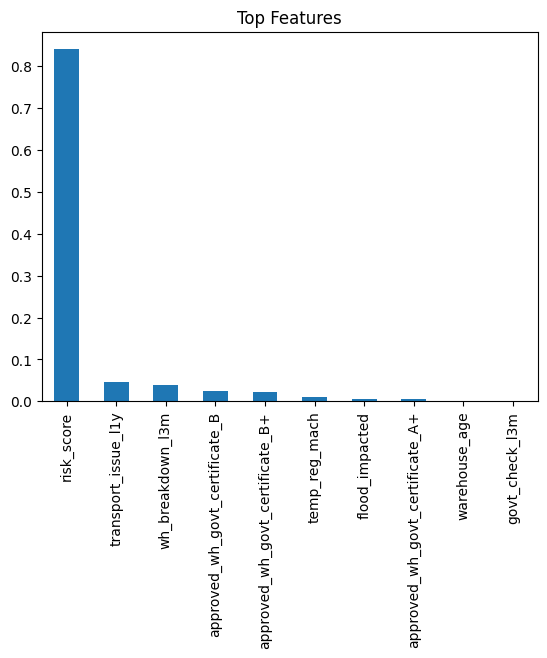

In [49]:
# step 8.10 Feature Importance 
import matplotlib.pyplot as plt

fi = pd.Series(xgb.feature_importances_, index=X_train.columns)
fi.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Features")
plt.show()

In [50]:
# step 8.11 Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb , X_train , y_train , cv = 5 , scoring="r2")
print("\nCV Scores : " , cv_scores)
print("Average CV Scores : " , cv_scores.mean())


CV Scores :  [0.99314886 0.99374962 0.99356359 0.99337393 0.99398959]
Average CV Scores :  0.9935651183128357


In [51]:
# step 8.12 : Hyperparameter Tuning 
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [4,6,8],
    "learning_rate": [0.01,0.05,0.1]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state = 42),
    param_distributions=param_grid,
    n_iter=10,
    scoring="r2",
    cv=3,
    n_jobs=-1
)

random_search.fit(X_train , y_train)
best_xgb = random_search.best_estimator_

In [52]:
# step 13 : Final Model Evaluation

best_pred = best_xgb.predict(X_test)

print("\nFinal Model Performance:")
print("R2:", r2_score(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("MAE:", mean_absolute_error(y_test, best_pred))


Final Model Performance:
R2: 0.9938519597053528
RMSE: 906.9768290161957
MAE: 692.6946654785156


In [54]:
# Feature Engineering Function
# This function applies the same transformations used during model training
# It ensures consistency between training data and prediction data

def feature_engineering(df):

    # Log transformations to reduce skewness
    df["log_dist_from_hub"] = np.log1p(df["dist_from_hub"])
    df["log_retail_shop"] = np.log1p(df["retail_shop_num"])
    df["log_distributor"] = np.log1p(df["distributor_num"])

    # Efficiency-related features
    df["worker_efficiency"] = df["workers_num"] / (df["retail_shop_num"] + 1)
    df["capacity_utilization"] = df["WH_capacity_size"] / (df["dist_from_hub"] + 1)

    # Risk score based on external factors
    df["risk_score"] = df["transport_issue_l1y"] + df["flood_impacted"]

    # Infrastructure score
    df["infra_score"] = df["electric_supply"] + df["temp_reg_mach"]

    # Market activity level
    df["market_activity"] = df["retail_shop_num"] + df["distributor_num"]

    # Distance efficiency
    df["distance_efficiency"] = df["retail_shop_num"] / (df["dist_from_hub"] + 1)

    # Supply efficiency calculation
    df["supply_efficiency"] = df["infra_score"] / (df["risk_score"] + 1)

    return df

In [58]:
# Fix all variables
features = top_features
model = best_xgb

In [59]:
#  STEP 14: TABLEAU DATASET GENERATION


# Create empty list to store generated data
data = []

# Generate multiple rows (simulate multiple warehouses / scenarios)
for i in range(100):

    # Generate random input values (simulating real-world data)
    retail_shop = np.random.randint(10, 200)
    workers = np.random.randint(5, 50)
    current_stock = np.random.randint(50, 500)

    # Create input dataframe (same structure as model input)
    input_df = pd.DataFrame([{
        "retail_shop_num": retail_shop,
        "dist_from_hub": np.random.uniform(5, 50),
        "WH_capacity_size": np.random.uniform(100, 1000),
        "distributor_num": np.random.randint(5, 100),
        "workers_num": workers,
        "transport_issue_l1y": np.random.randint(0, 2),
        "flood_impacted": np.random.randint(0, 2),
        "electric_supply": np.random.randint(0, 2),
        "temp_reg_mach": np.random.randint(0, 2),
        "govt_check_l3m": np.random.randint(0, 5)
    }])

    # Apply feature engineering (same as training)
    input_df_fe = feature_engineering(input_df)

    # Align features with model input (important step)
    input_df_fe = input_df_fe.reindex(columns=features, fill_value=0)

    # Predict demand using trained model
    prediction = model.predict(input_df_fe)[0]

    # Apply business logic (compare stock vs demand)
    difference = abs(current_stock - prediction)

    if current_stock > prediction:
        status = "Overstock"
        action = "Transfer stock"
    elif current_stock < prediction:
        status = "Stock-out"
        action = "Increase supply"
    else:
        status = "Balanced"
        action = "No action"

    # Save final row (this becomes one record in dataset)
    data.append({
        "warehouse": f"WH_{i+1}",   # Unique warehouse ID (important for Tableau)

        "retail_shop_num": retail_shop,
        "workers_num": workers,
        "predicted_demand": prediction,
        "current_stock": current_stock,
        "difference": difference,
        "status": status,
        "action": action
    })

# Convert list into DataFrame
final_df = pd.DataFrame(data)

# Save dataset as CSV file (for Tableau)
final_df.to_csv("tableau_dataset.csv", index=False)

print(" Dataset ready for Tableau ")

 Dataset ready for Tableau 


In [ ]:
import joblib

# Save trained model
joblib.dump(best_xgb, "model.pkl")

# Save feature list
joblib.dump(top_features, "features.pkl")

['features.pkl']

****Step NO 9 : End-to-End FMCG Demand Prediction with Streamlit Deployment****

In [ ]:
# Step 1 : Import Libraries 
import streamlit as st   # For building web app UI 
import pandas as pd      # For handling data 
import numpy as np       # For numerical operations 
import joblib            # For loading trained ML model 

In [ ]:
# Step 2 : Page Configuration 
# Setting page configuration

st.set_page_config(
    page_title="Demand Prediction App",      # Title shown on browser tab
    layout= "wide"                           # Full- width layout
) 

# App heading and description 
st.title("FMCG Demand Prediction App")
st.markdown("Prediction warehouse  demand and optimize supply allocation")

2026-04-08 00:21:21.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.475 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.476 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.476 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.477 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
# Step 3 : Load Model (Using Funcion + Caching)
# Function to load model and features 
# @st.cache_resource ensures model loads only once (improves performance )
@st.cache_resource
def load_model():
    try:
        model = joblib.load("model.pkl")       # Load trained model
        features = joblib.load("features.pkl") # Load feature list 
        return model , features
    except:
        return None , None

# Calling the function
model , features = load_model()

# If model not loaded , stop execution 
if model is None :
    st.error("Model or feature file not found. ")
    st.stop()

2026-04-08 00:21:21.492 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.494 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
# Step 4 : Sidebar Inputs (Using Functions)
# Function to take user input from sidebar 

def get_user_input():
    st.sidebar.header("Input Parameters")
    # Creating input dictionary 
    data = {
        "retail_shop_num": st.sidebar.number_input("Retail Shops" , 0 , 1000 , 50),
        "dist_from_hub": st.sidebar.number_input("Distance from Hub" , 0.0 , 500.0 , 10.0),
        "WH_capacity_size": st.sidebar.number_input("Warehouse Capacity" , 0.0 , 10000.0 , 500.0),
        "distributor_num": st.sidebar.number_input("Distributors" , 0 , 500 , 20),
        "workers_num": st.sidebar.number_input("Workers" , 0 , 500 , 10),
        "transport_issue_l1y": st.sidebar.selectbox("Transport Issue" ,[0,1]),
        "flood_impacted": st.sidebar.selectbox("Flood Impacted" ,[0,1]),
        "electric_supply": st.sidebar.selectbox("Electric Supply" ,[0,1]),
        "temp_reg_mach": st.sidebar.selectbox("Temp Reg Machine" ,[0,1]),
        "govt_check_13m": st.sidebar.number_input("Govt Checks (last 3 months)" ,0 , 50 , 2)
    }
    
    # Convert Dictionary to DataFrame
    return pd.DataFrame([data])

# Get User Input
input_data = get_user_input()    
        

2026-04-08 00:21:21.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.509 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.511 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.513 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
 # Step 5 : Input Validation 
 # Validate User input (example : no negative values )
if input_data["retail_shop_num"][0] < 0:
    st.error("Invalid Input")
    st.stop()
     

In [ ]:
# Step 6 : Feature Engineering Funcion
# Function to apply same feature engineering used during training

def feature_engineering(df):
    
    # Log transformation (to reduce skewness)
    df["log_dist_from_hub"] = np.log1p(df["dist_from_hub"])
    df["log_retail_shop"] = np.log1p(df["retail_shop_num"])
    df["log_distributor"] = np.log1p(df["distributor_num"])
    
    # Efficiency features
    df["worker_efficiency"] = df["workers_num"] / (df["retail_shop_num"] + 1)
    df["capacity_utilization"] = df["WH_capacity_size"] / (df["dist_from_hub"] + 1)
    
    # Risk Score (external disruptions)
    df["risk_score"] = df["transport_issue_l1y"] + df["flood_impacted"]
    
    # Infrastructure score
    df["infra_score"] = df["electric_supply"] + df["temp_reg_mach"]
    
    # Market Activit 
    df["market_activity"] = df["retail_shop_num"] + df["distributor_num"]
    
    # Distance efficiency
    df["distance_efficiency"] = df["retail_shop_num"] / (df["dist_from_hub"] + 1)
    
    # Supply efficiency
    df["supply_efficiency"] = df["infra_score"] / (df["risk_score"]  + 1)
    
    return df

In [ ]:
# Step 7 ; Prediction Button + Pipeline Execution
# Run prediction when button is clicked 

if st.sidebar.button("Predict Demand"):
    
    try:
        # Feature engineering
        input_data = feature_engineering(input_data)
        
        # Align features
        input_data = input_data.reindex(columns=features, fill_value=0)
        
        # Prediction
        prediction = model.predict(input_data)[0]

        # Output
        st.write("Prediction:", prediction)

    except Exception as e:
        # Error handling
        st.error(f"Error: {e}")

2026-04-08 00:21:21.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
if st.sidebar.button("Predict Demand"):
    
    try:
        # Feature engineering
        input_data = feature_engineering(input_data)
        
        # Align features
        input_data = input_data.reindex(columns=features, fill_value=0)
        
        # Prediction
        prediction = model.predict(input_data)[0]
        
        
        # OUTPUT UI (IMPORTANT 🔥)
        
        st.subheader("Prediction Result")

        col1, col2 = st.columns(2)

        with col1:
            st.metric("Predicted Demand (tons)", round(prediction, 2))

        with col2:
            if prediction > 300:
                st.success("High Demand Zone - Increase Supply")
            elif prediction > 100:
                st.warning("Moderate Demand")
            else:
                st.error("Low Demand - Reduce Supply")

    except Exception as e:
        st.error(f"Error: {e}")

2026-04-08 00:21:21.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
# Step 9 : Business Insight 
# Show business insight
st.markdown("Business Insight")
st.write(
    "This prediction helps optimize supply allocation ."
    "Increase supply in high - demand zones and reduce overstock in low - demand zones."
)

2026-04-08 00:21:21.590 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.596 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.596 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.597 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 00:21:21.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
